In [1]:
import sys
import os
import glob
import subprocess
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# Configure Matplotlib for inline display
%matplotlib inline
plt.rcParams['figure.figsize'] = [20, 6]
plt.rcParams['font.size'] = 12

# --- CONFIGURATION -----------------------------------------------------------
# 1. Path to where your C++ renderer saved the images
#    Use "." if they are in the same folder as this notebook.
#    Use "../bin/release" (or similar) if they are in a build folder.
input_dir = "../bin/release"  

# 2. The prefix of your screenshots
dataset_name = "csafe_heptane_302x302x302_uint8" 

# 3. The metric you want to analyze
metric_type  = "f2" 
# -----------------------------------------------------------------------------

In [2]:
def load_image_rgb(path):
    """Loads an image and converts BGR (OpenCV) to RGB (Matplotlib)."""
    if not os.path.exists(path):
        return None
    img = cv2.imread(path)
    if img is None: return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def run_flip_analysis(ref_path, test_path):
    """
    Robust version: Uses absolute paths and ignores non-fatal warnings.
    """
    # 1. Setup Absolute Paths
    # We want the output to be exactly where this notebook is
    current_dir = os.path.abspath(os.getcwd())
    temp_filename = "flip_temp" # Do not add .png here, FLIP adds it
    
    # Expected output file (FLIP 1.7+ typically defaults to PNG)
    expected_output = os.path.join(current_dir, f"{temp_filename}.png")
    
    # Clean up previous run if it exists
    if os.path.exists(expected_output):
        os.remove(expected_output)

    # 2. Locate FLIP Binary
    venv_bin = os.path.dirname(sys.executable)
    flip_executable = os.path.join(venv_bin, "flip")
    if not os.path.exists(flip_executable):
        flip_executable = "flip" # Fallback to PATH

    # 3. Construct Command
    cmd = [
        flip_executable,
        "--reference", os.path.abspath(ref_path),
        "--test", os.path.abspath(test_path),
        "--directory", current_dir,     # Force output to this folder
        "--basename", temp_filename,    # Output name (without extension)
        "--overwrite"
    ]
    
    # 4. Run without crashing on warnings (check=False)
    # We capture output to debug if needed, but don't stop execution
    proc = subprocess.run(cmd, capture_output=True, text=True, check=False)
    
    # 5. Check if the file was actually created
    if os.path.exists(expected_output):
        # Success! Load the image
        img = cv2.imread(expected_output)
        if img is not None:
            return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # --- Debugging Block (Only runs if image is missing) ---
    print(f"⚠️  FLIP Output Missing for: {os.path.basename(test_path)}")
    print(f"   Looking for: {expected_output}")
    print(f"   Exit Code: {proc.returncode}")
    
    # Did it save with a different name? (e.g. flip_temp.png.png)
    possible_files = glob.glob(os.path.join(current_dir, "flip_temp*"))
    if possible_files:
        print(f"   Found similar files: {possible_files}")
    else:
        print("   No output files found.")
        print("   Tool Output:", proc.stderr)
        
    return None

def calculate_metrics(ref_img, test_img, ref_path, test_path):
    """Computes PSNR, SSIM, and FLIP."""
    # 1. PSNR (Signal Fidelity)
    psnr_val = cv2.PSNR(ref_img, test_img)
    
    # 2. SSIM (Structural Similarity)
    ssim_val = ssim(ref_img, test_img, channel_axis=2, data_range=255)
    
    # 3. FLIP (Perceptual Error)
    flip_map = run_flip_analysis(ref_path, test_path)
    
    mean_flip = 1.0 # Default max error
    if flip_map is not None:
        # Normalize 0-255 image to 0-1 float
        mean_flip = np.mean(flip_map) / 255.0
        
    return {
        "psnr": psnr_val,
        "ssim": ssim_val,
        "mean_flip": mean_flip,
        "flip_map": flip_map
    }

In [3]:
def plot_comparison(ref, test, flip_map, metrics, quality_label):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # 1. Reference Image
    axes[0].imshow(ref)
    axes[0].set_title("Reference (Quality 1.00)", fontweight='bold')
    axes[0].axis('off')
    
    # 2. Compressed Test Image
    axes[1].imshow(test)
    axes[1].set_title(f"Compressed (Quality {quality_label})", fontweight='bold')
    axes[1].axis('off')
    
    # 3. FLIP Error Map
    if flip_map is not None:
        axes[2].imshow(flip_map)
        axes[2].set_title(f"FLIP Error Map (Mean: {metrics['mean_flip']:.4f})", color='darkred', fontweight='bold')
    else:
        axes[2].text(0.5, 0.5, "FLIP Computation Failed", ha='center')
    axes[2].axis('off')
    
    # Add a stats box to the right
    stats_text = (
        f"METRICS:\n"
        f"────────\n"
        f"PSNR: {metrics['psnr']:.2f} dB\n"
        f"SSIM: {metrics['ssim']:.4f}\n"
        f"FLIP: {metrics['mean_flip']:.4f}"
    )
    
    plt.figtext(0.92, 0.5, stats_text, fontsize=12, family='monospace',
                bbox=dict(boxstyle="round,pad=0.5", fc="#f4f4f4", ec="gray"))
    
    plt.show()

✅ Reference found: ../bin/release/csafe_heptane_302x302x302_uint8_f2_1.00.png
🔎 Searching for: ../bin/release/csafe_heptane_302x302x302_uint8_f2_*.png
   Found 4 variations. Starting analysis...



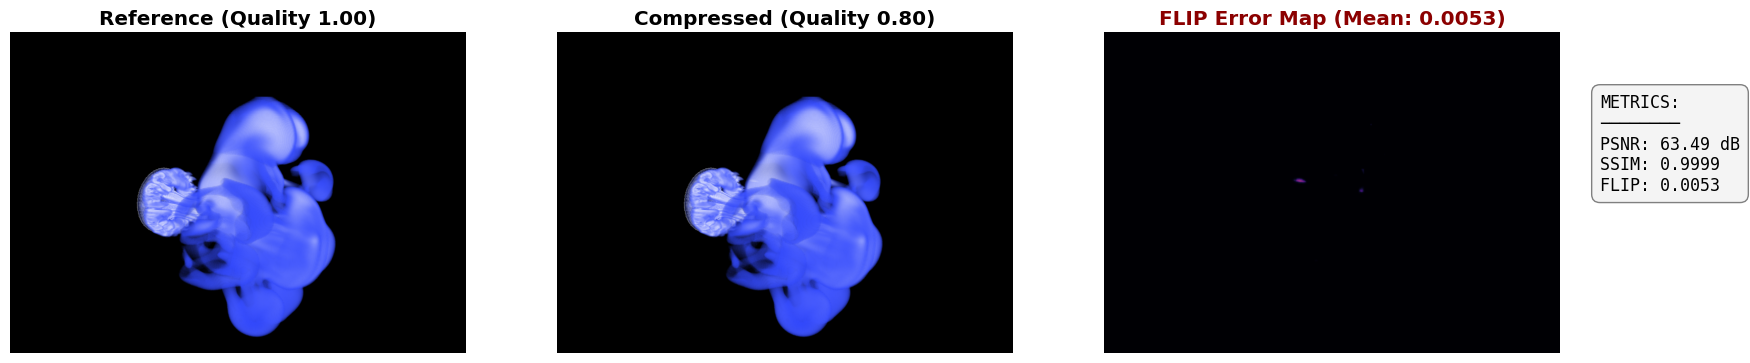

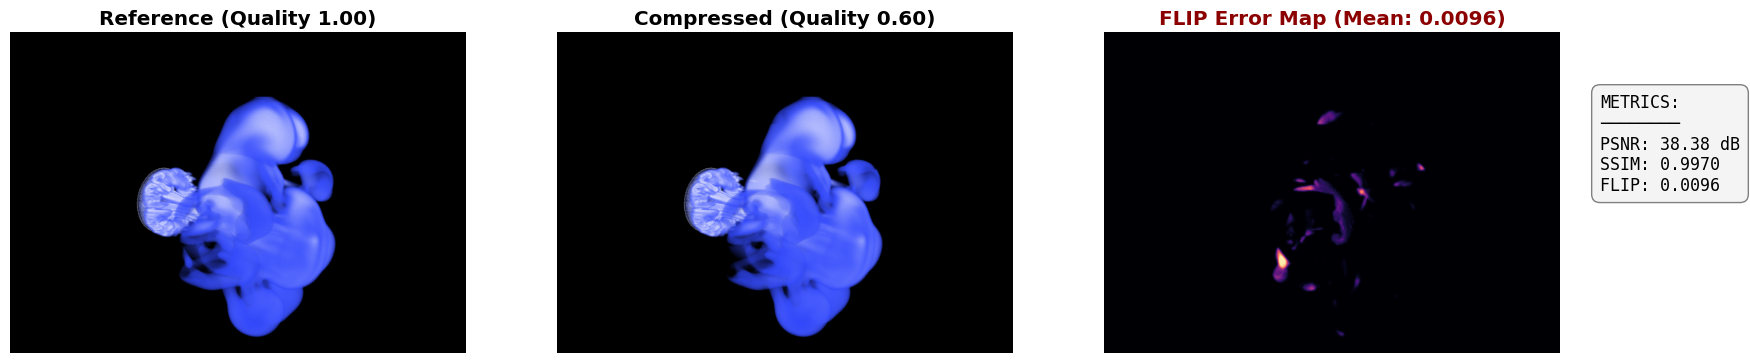

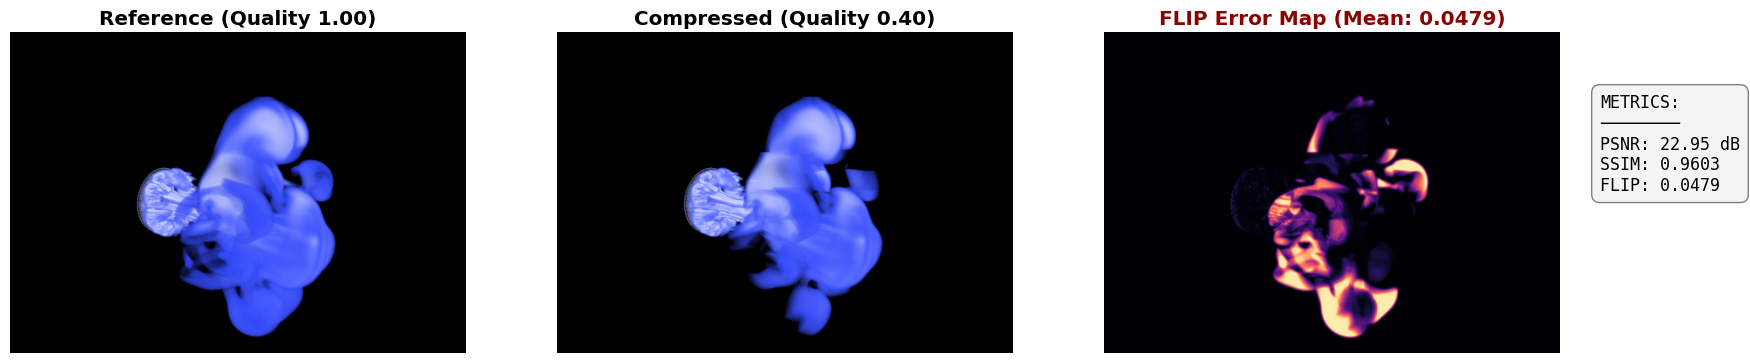

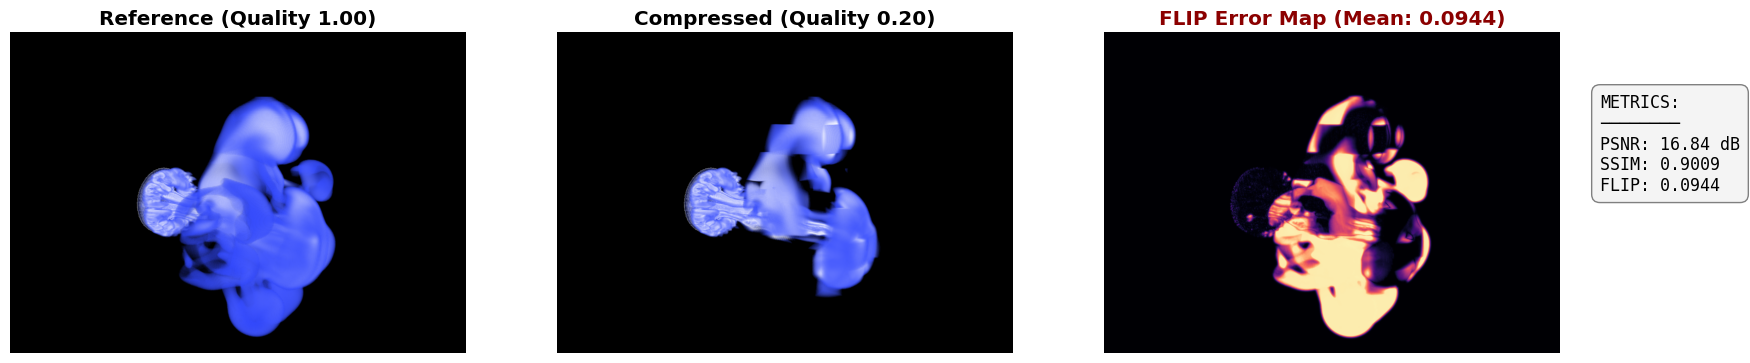


📊 SUMMARY REPORT


,PSNR (dB),SSIM,Mean FLIP
Quality,,,
0.800000,63.494621,0.999936,0.005330
0.600000,38.376148,0.996982,0.009599
0.400000,22.951264,0.960336,0.047860
0.200000,16.844586,0.900911,0.094358


In [4]:
# 1. Construct Paths
# Join the directory + dataset_name + metric + suffix
ref_filename = os.path.join(input_dir, f"{dataset_name}_{metric_type}_1.00.png")

if not os.path.exists(ref_filename):
    print(f"❌ Error: Reference image not found at:")
    print(f"   {ref_filename}")
    print("\nCheck your 'input_dir' variable in the config cell.")
else:
    print(f"✅ Reference found: {ref_filename}")
    ref_img = load_image_rgb(ref_filename)
    
    # 2. Find Test Images
    # Construct search pattern: "path/to/folder/dataset_f2_*.png"
    search_pattern = os.path.join(input_dir, f"{dataset_name}_{metric_type}_*.png")
    
    # Debug: Print what we are looking for
    print(f"🔎 Searching for: {search_pattern}")
    
    all_files = glob.glob(search_pattern)
    
    # Filter out the 1.00 reference image
    test_files = [f for f in all_files if "1.00.png" not in f]
    
    # Sort files by quality descending
    test_files.sort(reverse=True)
    
    if len(test_files) == 0:
        print("❌ No compressed variations found.")
        print("   Detected files in folder:", all_files)
    else:
        print(f"   Found {len(test_files)} variations. Starting analysis...\n")
        
        results_data = []

        for test_path in test_files:
            # Extract quality label from filename (e.g. "0.20")
            # We assume filename ends in "_0.20.png"
            filename = os.path.basename(test_path)
            quality_label = filename.split('_')[-1].replace('.png', '')
            
            test_img = load_image_rgb(test_path)
            
            # Safety Resize
            if ref_img.shape != test_img.shape:
                test_img = cv2.resize(test_img, (ref_img.shape[1], ref_img.shape[0]))
                
            # Calculate Metrics
            m = calculate_metrics(ref_img, test_img, ref_filename, test_path)
            
            results_data.append({
                "Quality": float(quality_label),
                "PSNR (dB)": m['psnr'],
                "SSIM": m['ssim'],
                "Mean FLIP": m['mean_flip']
            })
            
            # Visual Output
            plot_comparison(ref_img, test_img, m['flip_map'], m, quality_label)

        # 3. Final Summary Table
        if results_data:
            df = pd.DataFrame(results_data)
            df = df.sort_values("Quality", ascending=False).set_index("Quality")
            
            print("\n📊 SUMMARY REPORT")
            display(df.style.background_gradient(cmap='RdYlGn', subset=['PSNR (dB)', 'SSIM'])\
                            .background_gradient(cmap='RdYlGn_r', subset=['Mean FLIP']))